**1. CONVOLUTIONAL AUTOENCODERS TRAINING**

In [2]:
import digitalhub as dh
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_NAME = "floods"
project = dh.get_project(PROJECT_NAME)
print(f"Project: {project.name}")

Project: floods


**SETUP PARAMETERS**

In [7]:
job_name = "check_v1"                                    
dataset = "Test" 
sensor = "OPT"    

n_channels = 2 if sensor == "SAR" else 10 # OPT

parameters = {
    "job_name": job_name,
    "dataset": dataset,
    "sensor": sensor,
    "ltae": False,
    "resume": False,
    "time_debug": False,
    
    "epochs": 10, 
    "batch_size": 16, 
    "lr": 1e-4, 
    "weight_decay": 1e-4,      
    "patch_size": 256, 
    "n_images": 4, 
    "n_channels": n_channels,                                            
    "num_channels_latent_space": 16,                                                                                             
    "workers": 0,
    "job_name": job_name,
    "dataset": dataset,
    "patience": 10,                                    
    "min_delta": 1e-4,                             
}

volumes = [
    {
        "volume_type": "ephemeral",
        "name": "volume-spazio-dati",
        "mount_path": "/data",      
        "spec": {"size": "200Gi"}   
    }
]

**BUILD ENVIRONMENT**

In [ ]:
autoencoder_2D_train_func = project.new_function(
    name= f'autoencoder_2D_{sensor}_{job_name}',
    kind="python",
    python_version="PYTHON3_10",
    code_src="../src/", 
    handler="train_autoencoder_2D", 
    base_image="pytorch/pytorch:2.1.2-cuda11.8-cudnn8-runtime",
    requirements=["pandas==2.3.3", "numpy==1.26.4", "rasterio==1.4.4", "tqdm==4.70.0", "tifffile==2024.8.30", "torch==2.1.2", "matplotlib==3.10.9", "digitalhub==0.15.11", "digitalhub-runtime-python==0.15.2", "zarr==2.18.0", "numcodecs==0.13.1", "xarray==2025.6.1"]
)

build = autoencoder_2D_train_func.run("build", wait=True)
print(f"BUILD: {build.status.state}")

2026-09-26 11:44:36,296 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a3ed95ea2f234637a7afb2f145f76eac to finish...
2026-09-26 11:44:41,303 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a3ed95ea2f234637a7afb2f145f76eac to finish...
2026-09-26 11:44:46,311 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a3ed95ea2f234637a7afb2f145f76eac to finish...
2026-09-26 11:44:51,320 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a3ed95ea2f234637a7afb2f145f76eac to finish...
2026-09-26 11:44:56,330 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a3ed95ea2f234637a7afb2f145f76eac to finish...
2026-09-26 11:45:01,338 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a3ed95ea2f234637a7afb2f145f76eac to finish...
2026-09-26 11:45:06,348 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a3ed95ea2f234637a7afb2f145f76eac to finish...
2026-09-26 11

BUILD: COMPLETED


**TRAINING**

In [9]:
run_autoencoder_2D = autoencoder_2D_train_func.run(
    action="job", 
    parameters=parameters, 
    volumes=volumes, 
    profile="1xv100-shared",                                       
    local_execution= False,                                
    wait=True
)

print(f"Run train_encoders avviato: {run_autoencoder_2D.id}")

2026-09-26 11:45:26,550 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ca141e9df99a427685e4b93700347b3a to finish...
2026-09-26 11:45:31,556 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ca141e9df99a427685e4b93700347b3a to finish...
2026-09-26 11:45:36,565 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ca141e9df99a427685e4b93700347b3a to finish...
2026-09-26 11:45:41,573 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ca141e9df99a427685e4b93700347b3a to finish...
2026-09-26 11:45:46,582 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ca141e9df99a427685e4b93700347b3a to finish...
2026-09-26 11:45:51,591 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ca141e9df99a427685e4b93700347b3a to finish...
2026-09-26 11:45:56,599 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ca141e9df99a427685e4b93700347b3a to finish...
2026-09-26 11

Run train_encoders avviato: ca141e9df99a427685e4b93700347b3a


**PLOTS**

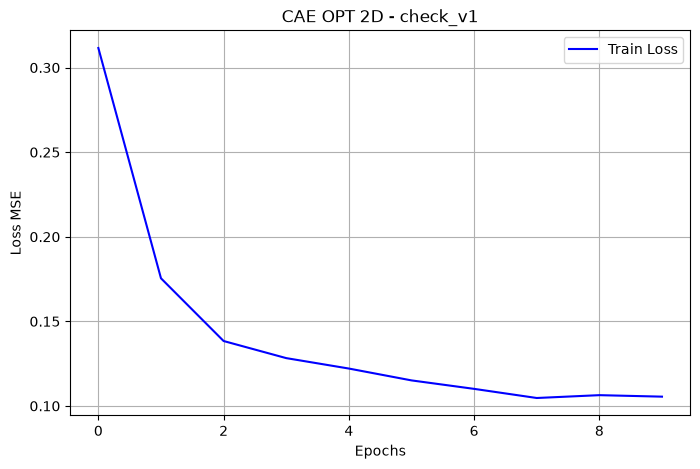

In [10]:
path = project.get_artifact(f"autoencoder_2D_{sensor}_metrics_{job_name}").download(overwrite=True)
df = pd.read_csv(path)

plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train_loss'], color='blue', label='Train Loss')
plt.title(f'CAE {sensor} 2D - {job_name}')
plt.xlabel('Epochs')
plt.ylabel('Loss MSE')
plt.grid(True)
plt.legend()
plt.show()